# CSS repetition-code decoding

This notebook decodes one CSS sector of a small GKP repetition code. It mirrors the surface-code CSS example: build one sector, run belief propagation on one displacement, check the residual, then run a compact distance sweep.

In [1]:
using Random
using LinearAlgebra
using LatticeDecoder

Random.seed!(4);

Build a distance-3 repetition code and select one CSS sector. With `bit_flip = false`, the protected qubit is encoded in the momentum basis, so this example decodes the reduced momentum-sector check matrix.

In [2]:
d = 3
bit_flip = false

code = GKP_Rep_Code(d, bit_flip, true);
M = code.code;

if bit_flip
    H = M[1:d, 1:d]
else
    H = M[(d + 1):end, (d + 1):end]
end

G = round.(sqrt(2) * inv(H)) / sqrt(2);
logical_check = inv(H);

(check_matrix_size = size(H), generator_size = size(G))

(check_matrix_size = (3, 3), generator_size = (3, 3))

Draw one Gaussian displacement, run serial belief propagation, then convert the continuous BP estimate into an integer correction.

In [3]:
noise_std = 0.05
max_iter = size(H, 2)
decoder = "lsd"
search_interval = 1.0

error_vector = sample_error(noise_std, size(H, 2));
received = copy(error_vector);

tanner_graph = initialize_tanner_graph(H);
bp_estimate = run_serial_belief_propagation!(
    tanner_graph,
    received,
    noise_std,
    max_iter,
    decoder;
    search_interval = search_interval,
);

decoded_integer_correction = hard_decision(bp_estimate, H);

order = ones(Int64, size(G, 2));
local_search_decoder = LocalSearch(length(order), G, order, false, false, false);
local_search_integer_correction = copy(decoded_integer_correction);
λ = abs.(H * bp_estimate) .% 1.0;
local_search!(received, λ, local_search_integer_correction, local_search_decoder);

Check whether the residual displacement is trivial up to the decoded sector lattice.

In [4]:
function is_not_logical_error(logical_check, residual; atol = 1e-5)
    logical_coordinates = logical_check' * residual
    return all(abs(x - round(x)) < atol for x in logical_coordinates)
end

bp_correction = received - G * decoded_integer_correction;
bp_residual = error_vector - bp_correction;

local_search_correction = received - G * local_search_integer_correction;
local_search_residual = error_vector - local_search_correction;

(bp_success = is_not_logical_error(logical_check, bp_residual),
 local_search_success = is_not_logical_error(logical_check, local_search_residual))

(bp_success = true, local_search_success = true)

## Small distance sweep

The next cells run a small CSS-sector sweep for `d = 3, 5, 7` over five noise values and plot the observed logical failure rate. This is intentionally small so the notebook remains an example; increase `samples_per_point` for smoother curves.

In [13]:
using Plots

function css_rep_code_sector(d; bit_flip = false)
    code = GKP_Rep_Code(d, bit_flip, true)
    M = code.code

    if bit_flip
        H = M[1:d, 1:d]
    else
        H = M[(d + 1):end, (d + 1):end]
    end

    G = round.(sqrt(2) * inv(H)) / sqrt(2)
    return H, G
end

function css_decode_fails(
    H,
    G,
    noise_std;
    decoder = "nearest",
    search_interval = 1.0,
    local_search = false,
    local_search_lll = false,
    sphere_decoding = false,
    full_basis = false,
    order = [2, 1, 1],
)
    logical_check = inv(H)
    error_vector = sample_error(noise_std, size(H, 2))
    received = copy(error_vector)
    tanner_graph = initialize_tanner_graph(H)

    bp_estimate = run_serial_belief_propagation!(
        tanner_graph,
        received,
        noise_std,
        size(H, 2),
        decoder;
        search_interval = search_interval,
    )

    decoded_integer_correction = hard_decision(bp_estimate, H)

    if local_search
        local_search_decoder = LocalSearch(
            length(order),
            G,
            order,
            local_search_lll,
            sphere_decoding,
            full_basis,
        )
        λ = abs.(H * bp_estimate) .% 1.0
        local_search!(received, λ, decoded_integer_correction, local_search_decoder)
    end

    correction = received - G * decoded_integer_correction
    residual = error_vector - correction

    return !is_not_logical_error(logical_check, residual)
end

css_decode_fails (generic function with 1 method)

In [14]:
distances = [3, 5, 7]
sigmas = collect(range(0.6, 1.0; length = 5)) ./ sqrt(2 * pi)
samples_per_point = 50_000

failure_rates = Dict{Int, Vector{Float64}}()

for distance in distances
    H_d, G_d = css_rep_code_sector(distance; bit_flip = bit_flip)
    rates = Float64[]

    for sigma in sigmas
        failures = count(_ -> css_decode_fails(H_d, G_d, sigma), 1:samples_per_point)
        push!(rates, failures / samples_per_point)
    end

    failure_rates[distance] = rates
end

for d in distances
    println("Distance $d failure rates: ", failure_rates[d])
end

Distance 3 failure rates: [0.03776, 0.0979, 0.1715, 0.24264, 0.31378]
Distance 5 failure rates: [0.01616, 0.05764, 0.12754, 0.20972, 0.28586]
Distance 7 failure rates: [0.00966, 0.04504, 0.11472, 0.1956, 0.2767]


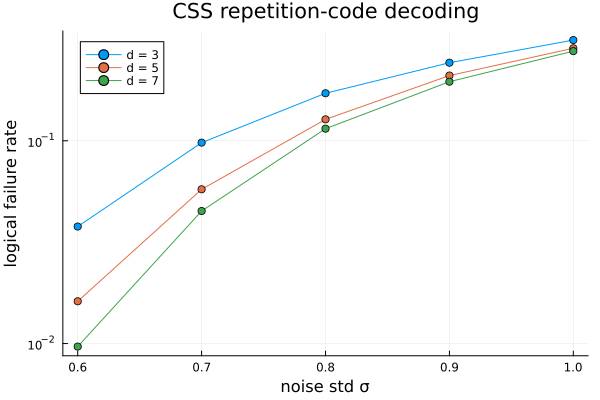

In [15]:
p = plot(
    xlabel = "noise std σ",
    ylabel = "logical failure rate",
    title = "CSS repetition-code decoding",
    legend = :topleft,
    yscale = :log10,
)

for distance in distances
    plot!(p, sigmas * sqrt(2 * pi), failure_rates[distance]; marker = :circle, label = "d = $(distance)")
end
p

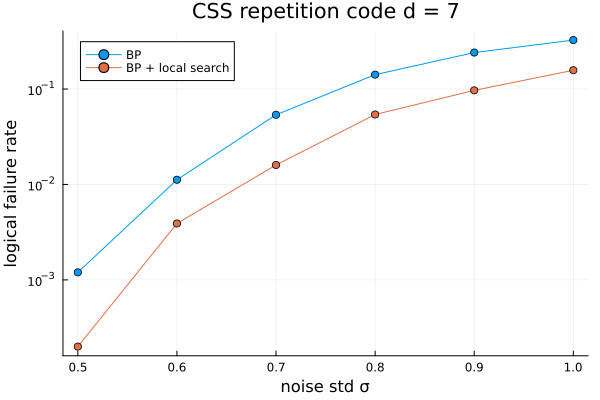

In [18]:
## Compact BP versus local-search comparison
comparison_distance = 7
comparison_samples = 10_000
comparison_sigmas = collect(range(0.5, 1.0; length = 6)) ./ sqrt(2 * pi)

H_cmp, G_cmp = css_rep_code_sector(comparison_distance; bit_flip = bit_flip)
comparison_failure_rates = Dict{String, Vector{Float64}}()

for (label, use_local_search) in ["BP" => false, "BP + local search" => true]
    rates = Float64[]
    for sigma in comparison_sigmas
        failures = count(
            _ -> css_decode_fails(
                H_cmp,
                G_cmp,
                sigma;
                decoder = "lsd",
                search_interval = search_interval,
                local_search = use_local_search,
            ),
            1:comparison_samples,
        )
        push!(rates, failures / comparison_samples)
    end
    comparison_failure_rates[label] = rates
end

p_compare = plot(
    xlabel = "noise std σ",
    ylabel = "logical failure rate",
    title = "CSS repetition code d = $(comparison_distance)",
    legend = :topleft,
    yscale = :log10,
)

for label in ["BP", "BP + local search"]
    plot!(
        p_compare,
        comparison_sigmas * sqrt(2 * pi),
        comparison_failure_rates[label];
        marker = :circle,
        label = label,
    )
end
p_compare